In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("IMDb movies.csv", low_memory=False)
df.shape

(85855, 22)

In [6]:
df.head()

,imdb_title_id,title,original_title,year,date_published,genre,duration,country,language,director,...,actors,description,avg_vote,votes,budget,usa_gross_income,worlwide_gross_income,metascore,reviews_from_users,reviews_from_critics
0,tt0000009,Miss Jerry,Miss Jerry,1894,1894-10-09,Romance,45,USA,NaN,Alexander Black,...,"Blanche Bayliss, William Courtenay, Chauncey D...",The adventures of a female reporter in the 1890s.,5.9,154,NaN,NaN,NaN,NaN,1.0,2.0
1,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,1906,12/26/1906,"Biography, Crime, Drama",70,Australia,NaN,Charles Tait,...,"Elizabeth Tait, John Tait, Norman Campbell, Be...",True story of notorious Australian outlaw Ned ...,6.1,589,"$2,250",NaN,NaN,NaN,7.0,7.0
2,tt0001892,Den sorte drøm,Den sorte drøm,1911,8/19/1911,Drama,53,"Germany, Denmark",NaN,Urban Gad,...,"Asta Nielsen, Valdemar Psilander, Gunnar Helse...",Two men of high rank are both wooing the beaut...,5.8,188,NaN,NaN,NaN,NaN,5.0,2.0
3,tt0002101,Cleopatra,Cleopatra,1912,11/13/1912,"Drama, History",100,USA,English,Charles L. Gaskill,...,"Helen Gardner, Pearl Sindelar, Miss Fielding, ...",The fabled queen of Egypt's affair with Roman ...,5.2,446,"$45,000",NaN,NaN,NaN,25.0,3.0
4,tt0002130,L'Inferno,L'Inferno,1911,3/6/1911,"Adventure, Drama, Fantasy",68,Italy,Italian,"Francesco Bertolini, Adolfo Padovan",...,"Salvatore Papa, Arturo Pirovano, Giuseppe de L...",Loosely adapted from Dante's Divine Comedy and...,7.0,2237,NaN,NaN,NaN,NaN,31.0,14.0


In [ ]:
# Select columns for Linear Regression
df_lr = df[['year', 'duration']].dropna()

df_lr.head()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85855 entries, 0 to 85854
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   imdb_title_id          85855 non-null  object 
 1   title                  85855 non-null  object 
 2   original_title         85855 non-null  object 
 3   year                   85855 non-null  object 
 4   date_published         85855 non-null  object 
 5   genre                  85855 non-null  object 
 6   duration               85855 non-null  int64  
 7   country                85791 non-null  object 
 8   language               84954 non-null  object 
 9   director               85768 non-null  object 
 10  writer                 84283 non-null  object 
 11  production_company     81400 non-null  object 
 12  actors                 85786 non-null  object 
 13  description            83740 non-null  object 
 14  avg_vote               85855 non-null  float64
 15  vo

In [8]:
df.isnull().sum()

imdb_title_id                0
title                        0
original_title               0
year                         0
date_published               0
genre                        0
duration                     0
country                     64
language                   901
director                    87
writer                    1572
production_company        4455
actors                      69
description               2115
avg_vote                     0
votes                        0
budget                   62145
usa_gross_income         70529
worlwide_gross_income    54839
metascore                72550
reviews_from_users        7597
reviews_from_critics     11797
dtype: int64

In [9]:
df.describe()

,duration,avg_vote,votes,metascore,reviews_from_users,reviews_from_critics
count,85855.000000,85855.000000,8.585500e+04,13305.000000,78258.000000,74058.000000
mean,100.351418,5.898656,9.493490e+03,55.896881,46.040826,27.479989
std,22.553848,1.234987,5.357436e+04,17.784874,178.511411,58.339158
min,41.000000,1.000000,9.900000e+01,1.000000,1.000000,1.000000
25%,88.000000,5.200000,2.050000e+02,43.000000,4.000000,3.000000
50%,96.000000,6.100000,4.840000e+02,57.000000,9.000000,8.000000
75%,108.000000,6.800000,1.766500e+03,69.000000,27.000000,23.000000
max,808.000000,9.900000,2.278845e+06,100.000000,10472.000000,999.000000


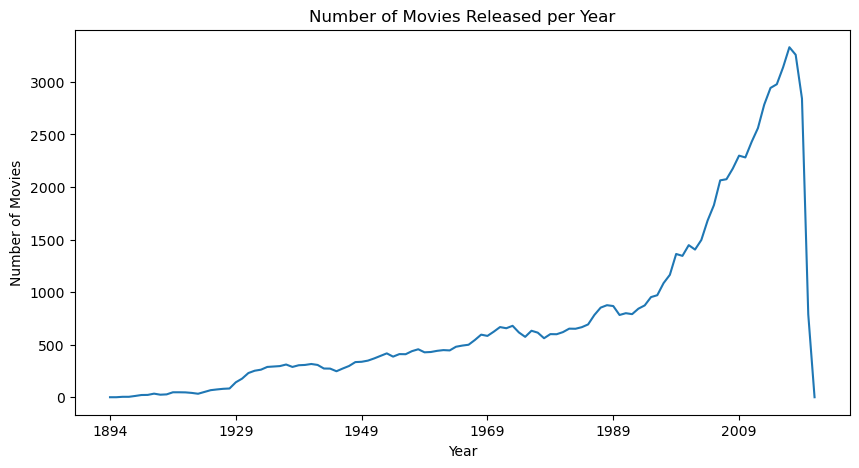

In [10]:
df['year'].value_counts().sort_index().plot(figsize=(10,5))
plt.title("Number of Movies Released per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

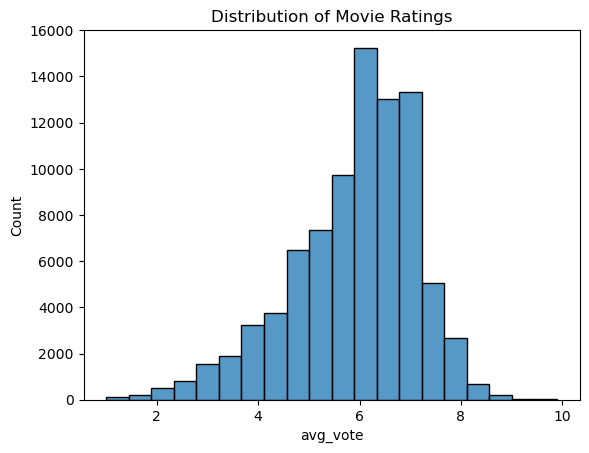

In [11]:
sns.histplot(df['avg_vote'], bins=20)
plt.title("Distribution of Movie Ratings")
plt.show()

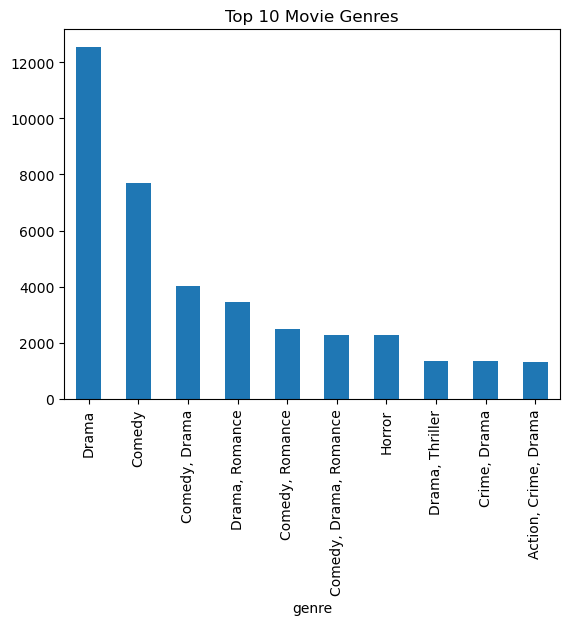

In [12]:
df['genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Movie Genres")
plt.show()

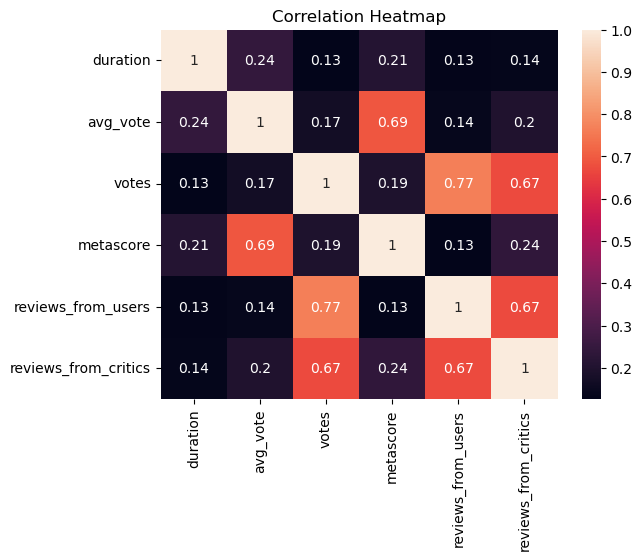

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

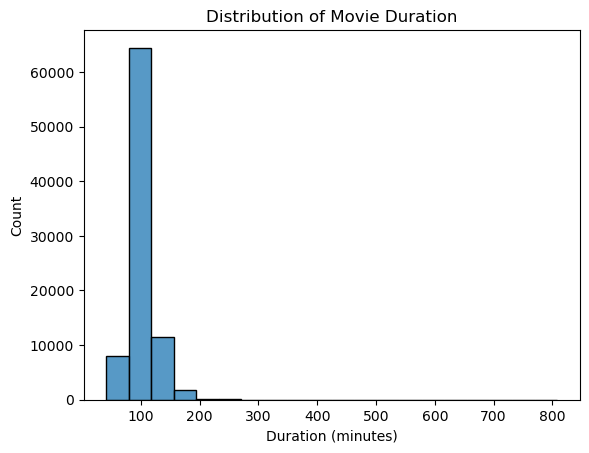

In [7]:
sns.histplot(df['duration'], bins=20)
plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.show()

In [14]:
# Cleaning Operation 1 – Check missing values
df.isnull().sum()

imdb_title_id                0
title                        0
original_title               0
year                         0
date_published               0
genre                        0
duration                     0
country                     64
language                   901
director                    87
writer                    1572
production_company        4455
actors                      69
description               2115
avg_vote                     0
votes                        0
budget                   62145
usa_gross_income         70529
worlwide_gross_income    54839
metascore                72550
reviews_from_users        7597
reviews_from_critics     11797
dtype: int64

In [15]:
# Cleaning Operation 2 – Remove duplicate rows
df = df.drop_duplicates()
df.shape

(85855, 22)

In [16]:
df['year'] = pd.to_numeric(df['year'], errors='coerce')

In [17]:
df = df.dropna(subset=['year'])

In [18]:
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

In [19]:
df = df[df['duration'] < 300]

In [20]:
df['language'] = df['language'].fillna('Unknown')

In [21]:
df.columns = df.columns.str.strip()

In [22]:
df.dtypes

imdb_title_id             object
title                     object
original_title            object
year                     float64
date_published            object
genre                     object
duration                   int64
country                   object
language                  object
director                  object
writer                    object
production_company        object
actors                    object
description               object
avg_vote                 float64
votes                      int64
budget                    object
usa_gross_income          object
worlwide_gross_income     object
metascore                float64
reviews_from_users       float64
reviews_from_critics     float64
dtype: object

In [24]:
# Cleaning Operation 10 – Reset index
df.reset_index(drop=True, inplace=True)
df.head()

,imdb_title_id,title,original_title,year,date_published,genre,duration,country,language,director,...,actors,description,avg_vote,votes,budget,usa_gross_income,worlwide_gross_income,metascore,reviews_from_users,reviews_from_critics
0,tt0000009,Miss Jerry,Miss Jerry,1894.0,1894-10-09,Romance,45,USA,Unknown,Alexander Black,...,"Blanche Bayliss, William Courtenay, Chauncey D...",The adventures of a female reporter in the 1890s.,5.9,154,NaN,NaN,NaN,NaN,1.0,2.0
1,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,1906.0,12/26/1906,"Biography, Crime, Drama",70,Australia,Unknown,Charles Tait,...,"Elizabeth Tait, John Tait, Norman Campbell, Be...",True story of notorious Australian outlaw Ned ...,6.1,589,"$2,250",NaN,NaN,NaN,7.0,7.0
2,tt0001892,Den sorte drøm,Den sorte drøm,1911.0,8/19/1911,Drama,53,"Germany, Denmark",Unknown,Urban Gad,...,"Asta Nielsen, Valdemar Psilander, Gunnar Helse...",Two men of high rank are both wooing the beaut...,5.8,188,NaN,NaN,NaN,NaN,5.0,2.0
3,tt0002101,Cleopatra,Cleopatra,1912.0,11/13/1912,"Drama, History",100,USA,English,Charles L. Gaskill,...,"Helen Gardner, Pearl Sindelar, Miss Fielding, ...",The fabled queen of Egypt's affair with Roman ...,5.2,446,"$45,000",NaN,NaN,NaN,25.0,3.0
4,tt0002130,L'Inferno,L'Inferno,1911.0,3/6/1911,"Adventure, Drama, Fantasy",68,Italy,Italian,"Francesco Bertolini, Adolfo Padovan",...,"Salvatore Papa, Arturo Pirovano, Giuseppe de L...",Loosely adapted from Dante's Divine Comedy and...,7.0,2237,NaN,NaN,NaN,NaN,31.0,14.0


In [25]:
df.shape

(85808, 22)

In [26]:
df.head()

,imdb_title_id,title,original_title,year,date_published,genre,duration,country,language,director,...,actors,description,avg_vote,votes,budget,usa_gross_income,worlwide_gross_income,metascore,reviews_from_users,reviews_from_critics
0,tt0000009,Miss Jerry,Miss Jerry,1894.0,1894-10-09,Romance,45,USA,Unknown,Alexander Black,...,"Blanche Bayliss, William Courtenay, Chauncey D...",The adventures of a female reporter in the 1890s.,5.9,154,NaN,NaN,NaN,NaN,1.0,2.0
1,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,1906.0,12/26/1906,"Biography, Crime, Drama",70,Australia,Unknown,Charles Tait,...,"Elizabeth Tait, John Tait, Norman Campbell, Be...",True story of notorious Australian outlaw Ned ...,6.1,589,"$2,250",NaN,NaN,NaN,7.0,7.0
2,tt0001892,Den sorte drøm,Den sorte drøm,1911.0,8/19/1911,Drama,53,"Germany, Denmark",Unknown,Urban Gad,...,"Asta Nielsen, Valdemar Psilander, Gunnar Helse...",Two men of high rank are both wooing the beaut...,5.8,188,NaN,NaN,NaN,NaN,5.0,2.0
3,tt0002101,Cleopatra,Cleopatra,1912.0,11/13/1912,"Drama, History",100,USA,English,Charles L. Gaskill,...,"Helen Gardner, Pearl Sindelar, Miss Fielding, ...",The fabled queen of Egypt's affair with Roman ...,5.2,446,"$45,000",NaN,NaN,NaN,25.0,3.0
4,tt0002130,L'Inferno,L'Inferno,1911.0,3/6/1911,"Adventure, Drama, Fantasy",68,Italy,Italian,"Francesco Bertolini, Adolfo Padovan",...,"Salvatore Papa, Arturo Pirovano, Giuseppe de L...",Loosely adapted from Dante's Divine Comedy and...,7.0,2237,NaN,NaN,NaN,NaN,31.0,14.0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85808 entries, 0 to 85807
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   imdb_title_id          85808 non-null  object 
 1   title                  85808 non-null  object 
 2   original_title         85808 non-null  object 
 3   year                   85808 non-null  float64
 4   date_published         85808 non-null  object 
 5   genre                  85808 non-null  object 
 6   duration               85808 non-null  int64  
 7   country                85744 non-null  object 
 8   language               85808 non-null  object 
 9   director               85721 non-null  object 
 10  writer                 84237 non-null  object 
 11  production_company     81355 non-null  object 
 12  actors                 85739 non-null  object 
 13  description            83695 non-null  object 
 14  avg_vote               85808 non-null  float64
 15  vo

In [28]:
df.describe()

,year,duration,avg_vote,votes,metascore,reviews_from_users,reviews_from_critics
count,85808.000000,85808.000000,85808.000000,8.580800e+04,13294.000000,78218.000000,74016.000000
mean,1993.506666,100.196578,5.898055,9.496630e+03,55.877614,46.053594,27.484895
std,24.209004,21.385359,1.234768,5.358809e+04,17.776342,178.553158,58.352189
min,1894.000000,41.000000,1.000000,9.900000e+01,1.000000,1.000000,1.000000
25%,1979.000000,88.000000,5.200000,2.050000e+02,43.000000,4.000000,3.000000
50%,2003.000000,96.000000,6.100000,4.850000e+02,57.000000,9.000000,8.000000
75%,2013.000000,108.000000,6.800000,1.767250e+03,69.000000,27.000000,23.250000
max,2020.000000,299.000000,9.900000,2.278845e+06,100.000000,10472.000000,999.000000


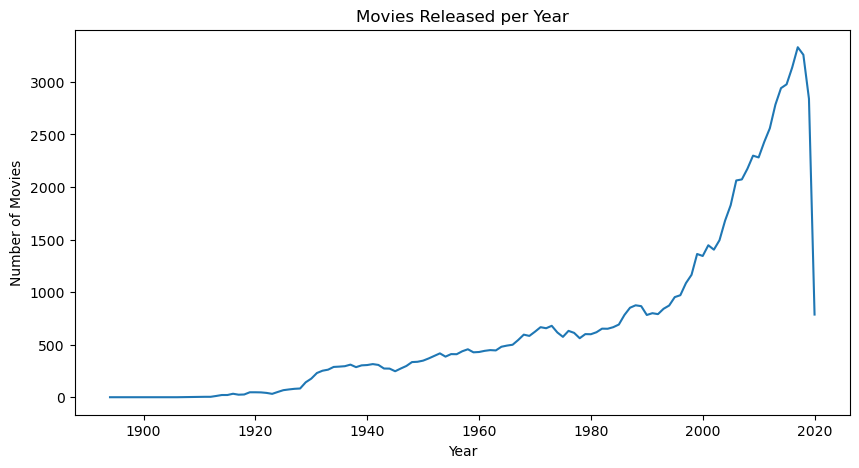

In [29]:
df['year'].value_counts().sort_index().plot(figsize=(10,5))
plt.title("Movies Released per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

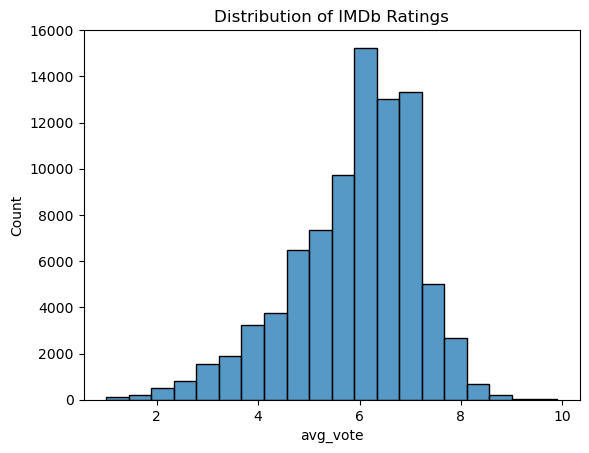

In [30]:
sns.histplot(df['avg_vote'], bins=20)
plt.title("Distribution of IMDb Ratings")
plt.show()

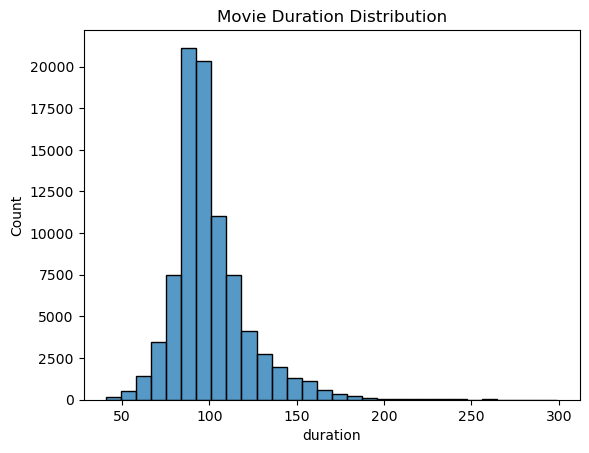

In [31]:
sns.histplot(df['duration'], bins=30)
plt.title("Movie Duration Distribution")
plt.show()

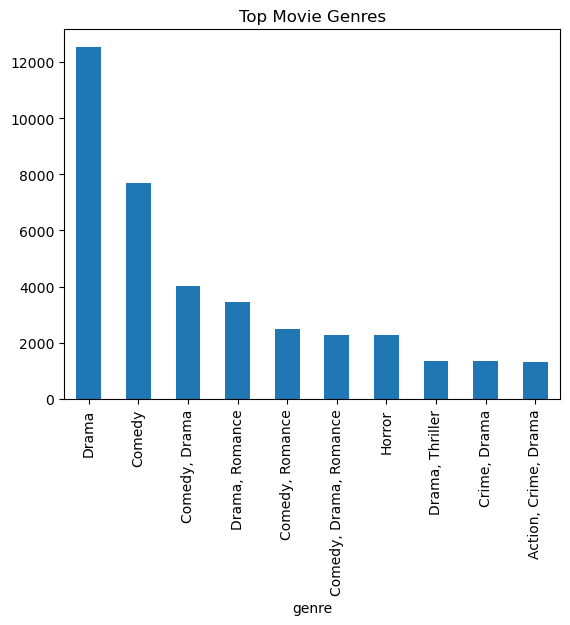

In [32]:
df['genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top Movie Genres")
plt.show()

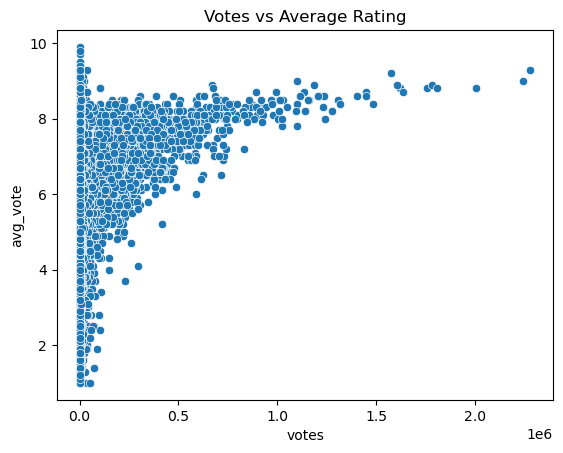

In [33]:
sns.scatterplot(x='votes', y='avg_vote', data=df)
plt.title("Votes vs Average Rating")
plt.show()

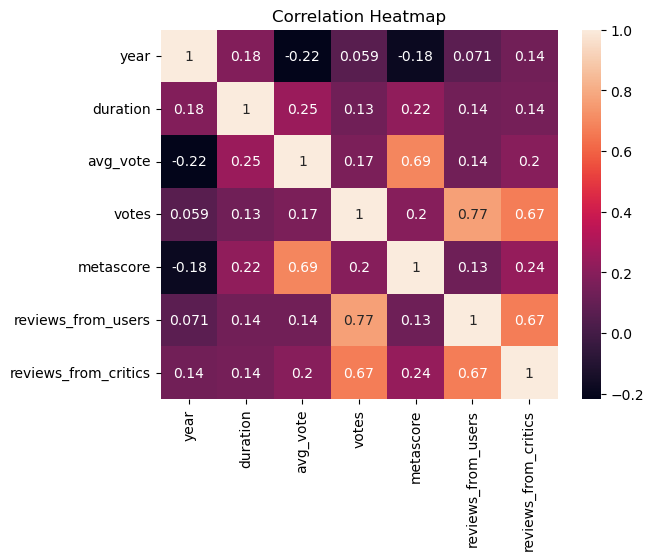

In [34]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()